In [39]:
from reinvent_lm.generation import MoleculeGenerator
from reinvent_lm.filters import StructureFilter

molecule_generator = MoleculeGenerator(tokenizer_path="checkpoints/reinvent_property_guided_2/tokenizer.json", config_path="configs/train_reinvent.yaml", checkpoint_path="checkpoints/reinvent_property_guided_2/checkpoint_epoch_30.pt", device="cuda")

使用設備: cuda
載入配置檔案: configs/train_reinvent.yaml
載入 tokenizer: checkpoints/reinvent_property_guided_2/tokenizer.json
Tokenizer 已從 checkpoints/reinvent_property_guided_2/tokenizer.json 加載
詞彙表大小: 26
建立模型...
載入模型權重: checkpoints/reinvent_property_guided_2/checkpoint_epoch_30.pt
✓ MoleculeGenerator 初始化完成 (從檢查點載入)!



（40 個無效分子已略過，不會顯示在圖片中）


/home/lungyi/miniconda3/envs/transformervae/lib/python3.13/site-packages/rdkit/Chem/Draw/IPythonConsole.py:343: UserWarning: Truncating the list of molecules to be displayed to 50. Change the maxMols value to display more.
  warnings.warn(


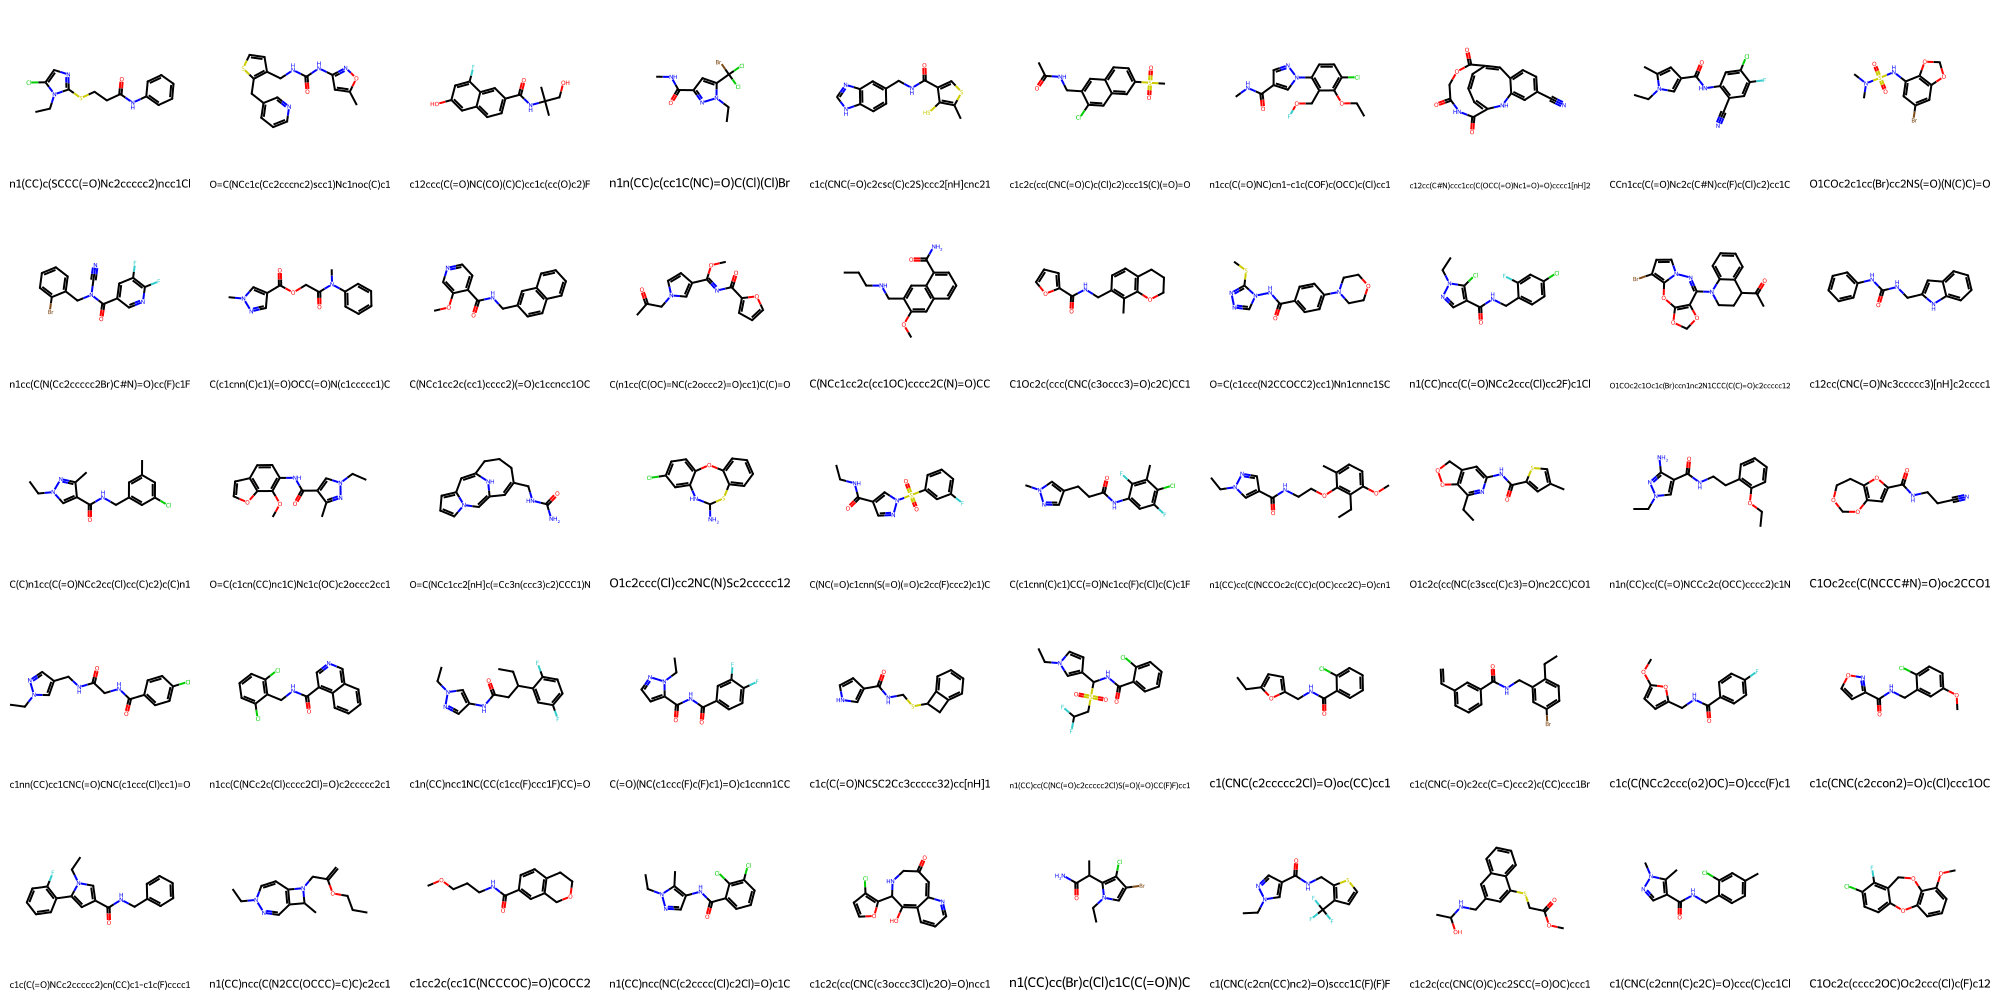

['O1c2c(ccc(Cl)c2)ClCNc2cccc(NS(=O)(=O)N3C)c21',
 'c1(C(NCc2ccccc2)=O)sc(-c2cnco2)no1',
 'n1(CC)c(SCCC(=O)Nc2ccccc2)ncc1Cl',
 'O=C(NCc1c(Cc2cccnc2)scc1)Nc1noc(C)c1',
 'c12ccc(C(=O)NC(CO)(C)C)cc1c(cc(O)c2)F',
 'O1COc2c(cccc2NC(Nc2ccsn3)=O)c1c[nH]2',
 'n1n(CC)c(cc1C(NC)=O)C(Cl)(Cl)Br',
 'c12cc(CNC(C1CC(C)(CC)OCC2)=O)cc(C)cc1F',
 'c1c(CNC(=O)c2csc(C)c2S)ccc2[nH]cnc21',
 'c1nn(CC)cc1C(=O)Nc1c2[nH]cc(SC)c2-c1o',
 'n1cc(C(=O)Nc2cc(OCn3ccccn3)[nH]2)[nH]c1',
 'c1c2c(cc(CNC(=O)C)c(Cl)c2)ccc1S(C)(=O)=O',
 'O=C(c1cnc2ccccc2n1NC(OC)=O)C#O',
 'n1cc(C(=O)NC)cn1-c1c(COF)c(OCC)c(Cl)cc1',
 'c12cc(C#N)ccc1cc(C(OCC(=O)Nc1=O)=O)cccc1[nH]2',
 'O=C(NCc1ccc2c(oc(Cl)c2)c1Cl)=O',
 'CCn1cc(C(=O)Nc2c(C#N)cc(F)c(Cl)c2)cc1C',
 'O1COc2c1cc(Br)cc2NS(=O)(N(C)C)=O',
 'n1cc(C(N(Cc2ccccc2Br)C#N)=O)cc(F)c1F',
 'C(c1cnn(C)c1)(=O)OCC(=O)N(c1ccccc1)C',
 'CCn1cc(C(NCc2nc3cc(Br)cc(F)n2C)=O)[nH]c1=O',
 'C(NCc1cc2c(cc1)cccc2)(=O)c1ccncc1OC',
 'C(n1cc(C(OC)=NC(c2occc2)=O)cc1)C(C)=O',
 'C(NCc1cc2c(cc1OC)cccc2C(N)=O)CC',
 'C1Oc2c(

In [40]:
molecule_generator.sample_from_prefix("CCn1cc(C(=O)NCc2ccc3c(c2)OCO3)cn1", 100, temperature=2., truncate_fraction_range=(0.2,0.4), display_molecules=True, seed=1)

In [34]:
from reinvent_lm.properties import PropertyInferenceAPI
from reinvent_lm.pareto import PropertySpec

filter_api = StructureFilter(max_ring_size=8, max_heavy_atoms=60,min_heavy_atoms=2, desired_smarts=["[C](=[O])-[N]","c1ccccc1"], require_all_desired=True)
property_specs = {"ClogP": PropertySpec(goal="maximize"), "SAScore": PropertySpec(goal="range", low=1.5, high=2.5), "MolWt": PropertySpec(goal="range", low=300, high=470)}

inference_api = PropertyInferenceAPI()
results = molecule_generator.generate_analogs(['Clc1c(Cl)c(NC(Nc2ccc(Cl)c(C)c2)=O)c(Br)cc1'], 10000, temperature=2., display_molecules=False, seed=1, inference_api=inference_api, filter_api=filter_api, target_spec=property_specs)

In [37]:
results[results["front_rank"]==1]

,smiles,seed,ClogP,SAScore,MolWt,front_rank
2,Clc1ccc(NC(Nc2c(Cl)c(Cl)ccc2Cl)=O)cc1Cl,Clc1c(Cl)c(NC(Nc2ccc(Cl)c(C)c2)=O)c(Br)cc1,6.5976,1.955308,384.477,1


In [38]:
filter_api = StructureFilter(max_ring_size=8, max_heavy_atoms=60,min_heavy_atoms=2, desired_smarts=["[C](=[O])-[N]","c1ccccc1"], require_all_desired=True)
results = molecule_generator.sample(1000,display_molecules=False)
results = filter_api(results)
results = inference_api.inference_pipeline(results, property_specs)
results

,smiles,ClogP,SAScore,MolWt
0,c1ccccc1S(=O)N(CC(NC(C)CCC)=O)CC,2.33590,3.390210,296.436
1,c1(NC(=O)Nc2sccn2)c(cc(Cl)cc1)C,3.74892,1.923889,267.741
2,Cc1cc(NC(=O)Cc2cccs2)cc(F)c1F,3.51592,2.096719,267.300
3,c1cc(C)c(OC(C)C(=O)Nc2ccccc2O)cc1,3.10662,2.123395,271.316
4,c1cc(NC(=O)CSc2nnc(C)s2)ccc1Cl,3.23072,1.868484,299.808
...,...,...,...,...
902,O=C(C)Nc1ccc(S(=O)(=O)NC(C)CC)cc1,1.72180,2.192254,270.354
903,n1ccccc1C(Nc1ccc(Cl)c(Cl)c1C)=O,3.94912,1.895653,281.142
904,C(NC(=O)Nc1cccc(Cl)c1)Cc1ccccc1,3.70420,1.485404,274.751
905,c1c(NC(=O)c2cc(Br)c(OC)cc2)ccc(C)c1,4.01842,1.491980,320.186


In [19]:
from reinvent_lm.tokenizer import randomize_smiles

randomize_smiles("CC(O)CCNC(OCCBr)CCl", seed=5)

'OC(CCNC(CCl)OCCBr)C'